# Exploratory Data Analysis

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
acs_pums_labels = {
    'AGEP':     'Age',
    'SEX':      'Sex',
    'RAC1P':    'Race (recoded, detailed)',
    'HISP':     'Hispanic origin',
    'NATIVITY': 'Nativity (native vs. foreign born)',
    'CIT':      'Citizenship status',
    'LANX':     'Speaks language other than English at home',
    'ENG':      'English-speaking ability',
    'MAR':      'Marital status',
    'MARHT':    'Number of times married',
    'RELSHIPP': 'Relationship to reference person',
    'FER':      'Gave birth in past 12 months',
    'GCL':      'Grandparent living with grandchildren',
    'NOP':      'Number of own children (verify — see note)',
    'PAOC':     'Presence and age of own children',
    'SCHL':     'Educational attainment',
    'SCH':      'School enrollment',
    'SCHG':     'Grade level attending',
    'FOD1P':    'Field of degree (primary)',
    'MIL':      'Military service status',
    'VPS':      'Veteran period of service',
    'DIS':      'Disability (recoded)',
    'DEAR':     'Hearing difficulty',
    'DEYE':     'Vision difficulty',
    'DREM':     'Cognitive difficulty',
    'DPHY':     'Ambulatory (physical) difficulty',
    'DDRS':     'Self-care difficulty',
    'DOUT':     'Independent-living difficulty',
    'COW':      'Class of worker',
    'ESR':      'Employment status (recoded)',
    'WKHP':     'Usual hours worked per week (past 12 months)',
    'WKWN':     'Weeks worked (past 12 months)',
    'OCCP':     'Occupation',
    'INDP':     'Industry',
    'JWMNP':    'Commute time to work (minutes)',
    'JWTRNS':   'Means of transportation to work',
    'POWPUMA':  'Place of work (PUMA)',
    'WRK':      'Worked last week',
    'MIG':      'Mobility status (lived here 1 year ago)',
    'MIGSP':    'State/country of residence 1 year ago',
    'HICOV':    'Health insurance coverage (any)',
    'PRIVCOV':  'Private health insurance coverage',
    'PUBCOV':   'Public health insurance coverage',
    'WAGP':     'Wage/salary income (past 12 months)',
    'SEMP':     'Self-employment income',
    'INTP':     'Interest, dividend & rental income',
    'RETP':     'Retirement income',
    'SSP':      'Social Security income',
    'SSIP':     'Supplementary Security Income',
    'PAP':      'Public assistance income', 
    'PERNP':    'Total earnings',
    'PINCP':    'Total personal income',
    'POVPIP':   'Income-to-poverty ratio',
    'ST':       'State (FIPS code)',
    'state_population': 'State population',
}

In [6]:
# TODO, select path dependent on data_pipline output
path = '../data_pipeline/data/manual__2026-06-10T22:40:01+00:00/synth/_full.parquet'
df = pd.read_parquet(path)

In [7]:
df.shape

(250000, 55)

In [8]:
num_features = df.describe().columns

num_df = df[num_features]
# num_df.rename(columns=acs_pums_labels, inplace=True)
cat_df = df.drop(columns=num_features)
cat_df.rename(columns=acs_pums_labels, inplace=True)

## Numerical Features

In [9]:
num_df.describe()

,AGEP,NOP,WKHP,WKWN,JWMNP,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,PERNP,PINCP,POVPIP,state_population
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,2.500000e+05
mean,43.078996,2.996680,37.953484,43.538188,26.492056,44947.689217,5828.988223,9234.929760,8801.790899,6130.018892,928.633243,291.639231,46233.798504,58264.198014,319.771004,6.634309e+06
std,22.788482,1.089782,9.725024,8.118215,14.141984,45851.061733,15188.654222,15054.559566,10775.865360,6369.991484,1226.440673,433.269605,51032.334706,58107.732189,136.879833,7.366752e+06
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-11594.035200,-7302.865500,0.000000,0.000000,0.000000,0.000000,-11594.035200,-12866.953500,0.000000,5.797610e+05
25%,27.000000,2.000000,31.000000,38.000000,17.000000,0.000000,-7882.458000,-2446.843200,0.000000,0.000000,0.000000,0.000000,-1791.807728,6844.091043,223.000000,1.893297e+06
50%,43.000000,3.000000,38.000000,45.000000,26.000000,34970.526255,2546.637090,2984.215760,4612.553139,4587.535571,312.769452,49.223106,38011.767363,50828.329365,330.000000,4.565875e+06
75%,59.000000,4.000000,44.000000,52.000000,36.000000,72793.867193,15369.823426,17427.645156,14918.863476,10213.275064,1591.445255,471.776300,78461.758292,95328.056085,437.000000,7.740984e+06
max,97.000000,8.000000,86.000000,52.000000,145.000000,395718.430922,116386.263715,125666.291052,85766.608344,45104.626477,9126.574740,5406.874547,405960.618538,431160.552287,501.000000,3.924278e+07


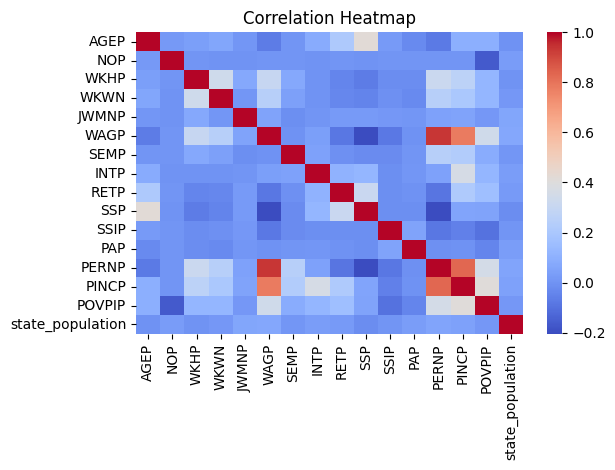

In [10]:
sns.heatmap(
   num_df.corr(),
   cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()

## Categorical Features

In [11]:
unique_values = cat_df.nunique().reset_index()
unique_values.columns = ['feature', 'n_unique']
unique_values

,feature,n_unique
0,Sex,2
1,"Race (recoded, detailed)",9
2,Hispanic origin,24
3,Nativity (native vs. foreign born),2
4,Citizenship status,5
5,Speaks language other than English at home,3
6,English-speaking ability,5
7,Marital status,5
8,Number of times married,4
9,Relationship to reference person,19


In [12]:
for col in cat_df.columns:
    print(cat_df[col].value_counts(normalize=True))
    print()

Sex
2    0.50756
1    0.49244
Name: proportion, dtype: float64

Race (recoded, detailed)
1    0.778020
2    0.065540
9    0.046528
4    0.042928
6    0.028796
8    0.021844
3    0.009720
7    0.005856
5    0.000768
Name: proportion, dtype: float64

Hispanic origin
01    0.905356
02    0.034992
18    0.014248
22    0.010784
12    0.007320
03    0.005260
24    0.003632
20    0.002396
10    0.001764
04    0.001696
15    0.001672
05    0.001368
21    0.001152
17    0.001140
11    0.001124
23    0.001044
09    0.001000
07    0.000976
06    0.000964
16    0.000924
08    0.000520
19    0.000420
13    0.000144
14    0.000104
Name: proportion, dtype: float64

Nativity (native vs. foreign born)
1    0.923144
2    0.076856
Name: proportion, dtype: float64

Citizenship status
1    0.914240
2    0.027540
4    0.025868
5    0.018340
3    0.014012
Name: proportion, dtype: float64

Speaks language other than English at home
2     0.862696
1     0.078896
NA    0.058408
Name: proportion, dtype: float64
